<a href="https://colab.research.google.com/github/syedthouheed128/Lungcancer-Classification/blob/main/LungCancer_TL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# LUNG CT DATASET - INSPECT DATASET IN COLAB /content
# ============================================================

import os
from pathlib import Path
from collections import Counter
from PIL import Image

# ------------------------------------------------------------
# 1. SET DATASET PATH
# ------------------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Lungcancer-dataset"

root = Path(DATASET_PATH)

if not root.exists():
    print("Dataset folder not found!")
    print("\nFolders currently inside /content:\n")

    for item in Path("/content").iterdir():
        print("📁" if item.is_dir() else "📄", item.name)

else:
    print("Dataset found!")
    print("Path:", root)

    # --------------------------------------------------------
    # 2. FOLDER STRUCTURE
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("FOLDER STRUCTURE")
    print("=" * 70)

    for path in sorted(root.rglob("*")):

        level = len(path.relative_to(root).parts) - 1
        indent = "    " * level

        if path.is_dir():
            print(f"{indent}📁 {path.name}/")

    # --------------------------------------------------------
    # 3. FIND ALL IMAGES
    # --------------------------------------------------------

    image_extensions = {
        ".jpg", ".jpeg", ".png",
        ".bmp", ".tif", ".tiff", ".webp"
    }

    images = [
        p for p in root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in image_extensions
    ]

    print("\n" + "=" * 70)
    print("IMAGE SUMMARY")
    print("=" * 70)

    print("Total images:", len(images))

    # --------------------------------------------------------
    # 4. COUNT IMAGES BY FOLDER
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("📊 IMAGES BY FOLDER")
    print("=" * 70)

    folder_counts = Counter()

    for img in images:
        folder = img.parent.relative_to(root)
        folder_counts[str(folder)] += 1

    for folder, count in sorted(folder_counts.items()):
        print(f"{folder:50s} : {count}")

    # --------------------------------------------------------
    # 5. SAMPLE FILES
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("📄 SAMPLE FILES")
    print("=" * 70)

    samples = {}

    for img in images:
        folder = str(img.parent.relative_to(root))

        if folder not in samples:
            samples[folder] = []

        samples[folder].append(img.name)

    for folder in sorted(samples):

        print(f"\n📁 {folder}")

        for filename in sorted(samples[folder])[:5]:
            print("   └──", filename)

    # --------------------------------------------------------
    # 6. IMAGE FORMATS
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("🗂️ IMAGE FORMATS")
    print("=" * 70)

    formats = Counter(
        img.suffix.lower()
        for img in images
    )

    for ext, count in formats.items():
        print(f"{ext:10s} : {count}")

    # --------------------------------------------------------
    # 7. IMAGE RESOLUTIONS
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("📐 IMAGE RESOLUTIONS")
    print("=" * 70)

    resolutions = Counter()
    unreadable = []

    for img_path in images:

        try:
            with Image.open(img_path) as im:
                resolutions[im.size] += 1

        except Exception:
            unreadable.append(img_path)

    for resolution, count in resolutions.most_common(10):
        print(
            f"{resolution[0]} x {resolution[1]} : {count}"
        )

    # --------------------------------------------------------
    # 8. LOOK FOR CLASS NAMES
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("🏷️ POSSIBLE CLASSES")
    print("=" * 70)

    class_keywords = [
        "normal",
        "benign",
        "malignant",
        "cancer",
        "healthy"
    ]

    for folder in folder_counts:

        lower = folder.lower()

        found = [
            word for word in class_keywords
            if word in lower
        ]

        if found:
            print(
                f"{folder}  -->  {', '.join(found).upper()}"
            )

    # --------------------------------------------------------
    # 9. FINAL SUMMARY
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("✅ FINAL DATASET SUMMARY")
    print("=" * 70)

    print("Dataset :", root)
    print("Images  :", len(images))
    print("Folders :", len(folder_counts))
    print("Formats :", dict(formats))

    if unreadable:
        print(
            "\n⚠️ Unreadable images:",
            len(unreadable)
        )

✅ Dataset found!
Path: /content/drive/MyDrive/Colab Notebooks/Lungcancer-dataset

📁 FOLDER STRUCTURE
📁 Bengin cases/
📁 Malignant cases/
📁 Normal cases/

🖼️ IMAGE SUMMARY
Total images: 1097

📊 IMAGES BY FOLDER
Bengin cases                                       : 120
Malignant cases                                    : 561
Normal cases                                       : 416

📄 SAMPLE FILES

📁 Bengin cases
   └── Bengin case (1).jpg
   └── Bengin case (10).jpg
   └── Bengin case (100).jpg
   └── Bengin case (101).jpg
   └── Bengin case (102).jpg

📁 Malignant cases
   └── Malignant case (1).jpg
   └── Malignant case (10).jpg
   └── Malignant case (100).jpg
   └── Malignant case (101).jpg
   └── Malignant case (102).jpg

📁 Normal cases
   └── Normal case (1).jpg
   └── Normal case (10).jpg
   └── Normal case (100).jpg
   └── Normal case (101).jpg
   └── Normal case (102).jpg

🗂️ IMAGE FORMATS
.jpg       : 1097

📐 IMAGE RESOLUTIONS
512 x 512 : 1036
623 x 512 : 31
801 x 512 : 28
506 x 33

In [ ]:
# ============================================================
# PHASE 1: DATASET LOADING & UNDERSTANDING
# Lung CT Cancer Dataset
# ============================================================

import os
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd

# ------------------------------------------------------------
# 1. DATASET PATH
# ------------------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Lungcancer-dataset"

dataset = Path(DATASET_PATH)

if not dataset.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}"
    )

print("✅ Dataset found")
print("📁 Location:", dataset)


# ------------------------------------------------------------
# 2. DISPLAY DATASET STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for path in sorted(dataset.rglob("*")):

    relative_path = path.relative_to(dataset)

    level = len(relative_path.parts) - 1
    indent = "    " * level

    if path.is_dir():
        print(f"{indent}📁 {path.name}/")


# ------------------------------------------------------------
# 3. FIND ALL CT IMAGE FILES
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

image_files = [
    path
    for path in dataset.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("\n" + "=" * 70)
print("IMAGE INFORMATION")
print("=" * 70)

print("Total images:", len(image_files))


# ------------------------------------------------------------
# 4. COUNT IMAGES IN EACH FOLDER
# ------------------------------------------------------------

folder_counts = Counter()

for image in image_files:

    relative_folder = image.parent.relative_to(dataset)

    folder_counts[str(relative_folder)] += 1


print("\n" + "=" * 70)
print("IMAGES PER FOLDER")
print("=" * 70)

for folder, count in sorted(folder_counts.items()):

    print(f"{folder:50s} : {count}")


# ------------------------------------------------------------
# 5. SHOW SAMPLE IMAGE NAMES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE IMAGE FILES")
print("=" * 70)

files_by_folder = {}

for image in image_files:

    folder = str(image.parent.relative_to(dataset))

    if folder not in files_by_folder:
        files_by_folder[folder] = []

    files_by_folder[folder].append(image)


for folder in sorted(files_by_folder):

    print(f"\n📁 {folder}")

    for image in files_by_folder[folder][:5]:

        print("   ", image.name)


# ------------------------------------------------------------
# 6. IMAGE FORMAT DISTRIBUTION
# ------------------------------------------------------------

format_counts = Counter(
    image.suffix.lower()
    for image in image_files
)

print("\n" + "=" * 70)
print("IMAGE FORMATS")
print("=" * 70)

for extension, count in sorted(format_counts.items()):

    print(f"{extension:10s} : {count}")


# ------------------------------------------------------------
# 7. IMAGE RESOLUTION ANALYSIS
# ------------------------------------------------------------

resolution_counts = Counter()
unreadable_images = []

for image in image_files:

    try:

        with Image.open(image) as img:

            resolution_counts[img.size] += 1

    except Exception:

        unreadable_images.append(image)


print("\n" + "=" * 70)
print("IMAGE RESOLUTIONS")
print("=" * 70)

for resolution, count in resolution_counts.most_common(10):

    width, height = resolution

    print(
        f"{width} x {height} : {count} images"
    )


# ------------------------------------------------------------
# 8. CHECK FOR UNREADABLE IMAGES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE QUALITY CHECK")
print("=" * 70)

if len(unreadable_images) == 0:

    print("✅ All images can be opened successfully.")

else:

    print(
        "⚠️ Unreadable images:",
        len(unreadable_images)
    )

    for image in unreadable_images[:10]:

        print(image)


# ------------------------------------------------------------
# 9. CREATE DATASET INVENTORY
# ------------------------------------------------------------

records = []

for image in image_files:

    try:

        with Image.open(image) as img:

            width, height = img.size

        relative_folder = image.parent.relative_to(dataset)

        records.append({
            "filename": image.name,
            "filepath": str(image),
            "class_folder": str(relative_folder),
            "extension": image.suffix.lower(),
            "width": width,
            "height": height
        })

    except:

        pass


df = pd.DataFrame(records)


# ------------------------------------------------------------
# 10. DISPLAY DATASET TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INVENTORY")
print("=" * 70)

display(df.head(10))


# ------------------------------------------------------------
# 11. SAVE INVENTORY
# ------------------------------------------------------------

inventory_path = "/content/lung_ct_dataset_inventory.csv"

df.to_csv(
    inventory_path,
    index=False
)

print("\n✅ Inventory saved to:")
print(inventory_path)


# ------------------------------------------------------------
# 12. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 1 COMPLETE")
print("=" * 70)

print("Dataset location :", DATASET_PATH)
print("Total images     :", len(image_files))
print("Image formats    :", dict(format_counts))
print("Unique resolutions:", len(resolution_counts))
print("Unreadable images:", len(unreadable_images))

print("\nFolder distribution:")

for folder, count in sorted(folder_counts.items()):

    print(f"  {folder} --> {count} images")

✅ Dataset found
📁 Location: /content/drive/MyDrive/Colab Notebooks/Lungcancer-dataset

DATASET STRUCTURE
📁 Bengin cases/
📁 Malignant cases/
📁 Normal cases/

IMAGE INFORMATION
Total images: 1097

IMAGES PER FOLDER
Bengin cases                                       : 120
Malignant cases                                    : 561
Normal cases                                       : 416

SAMPLE IMAGE FILES

📁 Bengin cases
    Bengin case (101).jpg
    Bengin case (102).jpg
    Bengin case (10).jpg
    Bengin case (1).jpg
    Bengin case (100).jpg

📁 Malignant cases
    Malignant case (11).jpg
    Malignant case (105).jpg
    Malignant case (141).jpg
    Malignant case (128).jpg
    Malignant case (140).jpg

📁 Normal cases
    Normal case (122).jpg
    Normal case (189).jpg
    Normal case (142).jpg
    Normal case (184).jpg
    Normal case (148).jpg

IMAGE FORMATS
.jpg       : 1097

IMAGE RESOLUTIONS
512 x 512 : 1036 images
623 x 512 : 31 images
801 x 512 : 28 images
506 x 331 : 1 images
511

,filename,filepath,class_folder,extension,width,height
0,Normal case (122).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
1,Normal case (189).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
2,Normal case (142).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
3,Normal case (184).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
4,Normal case (148).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
5,Normal case (130).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
6,Normal case (107).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
7,Normal case (174).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
8,Normal case (167).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512
9,Normal case (137).jpg,/content/drive/MyDrive/Colab Notebooks/Lungcan...,Normal cases,.jpg,512,512



✅ Inventory saved to:
/content/lung_ct_dataset_inventory.csv

PHASE 1 COMPLETE
Dataset location : /content/drive/MyDrive/Colab Notebooks/Lungcancer-dataset
Total images     : 1097
Image formats    : {'.jpg': 1097}
Unique resolutions: 5
Unreadable images: 0

Folder distribution:
  Bengin cases --> 120 images
  Malignant cases --> 561 images
  Normal cases --> 416 images


In [ ]:
# ============================================================
# PHASE 2: PREPROCESSING
# ============================================================

import os
import shutil
import random
from pathlib import Path
from PIL import Image
import pandas as pd

BASE = Path("/content")

# ------------------------------------------------------------
# 1. FIND CLASS FOLDERS
# ------------------------------------------------------------

keywords = {
    "normal": ["normal"],
    "benign": ["benign", "bengin"],
    "malignant": ["malignant"]
}

class_folders = {
    "normal": [],
    "benign": [],
    "malignant": []
}

for folder in BASE.rglob("*"):
    if folder.is_dir():
        name = folder.name.lower()

        for class_name, names in keywords.items():
            if any(word in name for word in names):
                class_folders[class_name].append(folder)

# ------------------------------------------------------------
# 2. CHECK CLASSES
# ------------------------------------------------------------

missing = [
    c for c in class_folders
    if len(class_folders[c]) == 0
]

if missing:
    raise RuntimeError(
        f"Could not find these classes: {missing}"
    )

# ------------------------------------------------------------
# 3. COLLECT IMAGES
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

class_images = {}

for class_name, folders in class_folders.items():

    images = []

    for folder in folders:
        for file in folder.rglob("*"):
            if (
                file.is_file()
                and file.suffix.lower() in IMAGE_EXTENSIONS
            ):
                images.append(file)

    class_images[class_name] = list(dict.fromkeys(images))

# ------------------------------------------------------------
# 4. CREATE OUTPUT FOLDERS
# ------------------------------------------------------------

OUTPUT = Path("/content/lung_ct_preprocessed")

if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in ["train", "validation", "test"]:
    for class_name in ["normal", "benign", "malignant"]:
        (OUTPUT / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

# ------------------------------------------------------------
# 5. PREPROCESSING SETTINGS
# ------------------------------------------------------------

IMAGE_SIZE = (224, 224)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

records = []

# ------------------------------------------------------------
# 6. SPLIT + RESIZE IMAGES
# ------------------------------------------------------------

for class_name in ["normal", "benign", "malignant"]:

    images = class_images[class_name].copy()

    random.shuffle(images)

    total = len(images)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    splits = {
        "train": images[:train_end],
        "validation": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():

        for i, source in enumerate(split_images):

            try:
                img = Image.open(source)
                img = img.convert("RGB")

                # Resize
                img = img.resize(
                    IMAGE_SIZE,
                    Image.Resampling.LANCZOS
                )

                filename = f"{class_name}_{i:05d}.jpg"

                destination = (
                    OUTPUT
                    / split_name
                    / class_name
                    / filename
                )

                img.save(
                    destination,
                    "JPEG",
                    quality=95
                )

                records.append({
                    "filename": filename,
                    "original_path": str(source),
                    "processed_path": str(destination),
                    "class": class_name,
                    "split": split_name
                })

            except Exception:
                pass

# ------------------------------------------------------------
# 7. SAVE CSV
# ------------------------------------------------------------

df = pd.DataFrame(records)

CSV_PATH = "/content/lung_ct_preprocessed.csv"

df.to_csv(
    CSV_PATH,
    index=False
)

# ------------------------------------------------------------
# 8. FINAL DATA DISTRIBUTION
# ------------------------------------------------------------

distribution = pd.crosstab(
    df["class"],
    df["split"]
)

print("FINAL DATA DISTRIBUTION")
display(distribution)

FINAL DATA DISTRIBUTION


split,test,train,validation
class,,,
benign,31,110,33
malignant,153,504,127
normal,108,361,89


Found 975 files belonging to 3 classes.
Found 249 files belonging to 3 classes.
Found 292 files belonging to 3 classes.
Classes: ['benign', 'malignant', 'normal']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 53s 794ms/step - accuracy: 0.6615 - loss: 0.8536 - val_accuracy: 0.8112 - val_loss: 0.5210
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 45s 728ms/step - accuracy: 0.8246 - loss: 0.4683 - val_accuracy: 0.8434 - val_loss: 0.3960
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 46s 753ms/step - accuracy: 0.8585 - loss: 0.3786 - val_accuracy: 0.8835 - val_loss: 0.3260
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 44s 733ms/step - accuracy: 0.8769 - loss: 0.3407 - val_accuracy: 0.8755 - val_loss: 0.3095
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 44s 732ms/step - accuracy: 0.8903 - loss: 0.2936 - val_accuracy: 0.8996 - val_loss: 0.2651
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 45s 743ms/step - accuracy: 0.9077 - loss: 0.2501 - val_accuracy: 0.8956 - val_loss: 0.2460
Epoch 7/10
61/

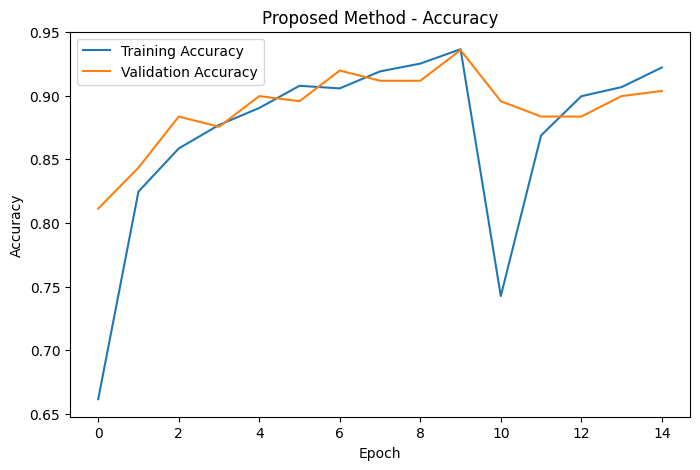

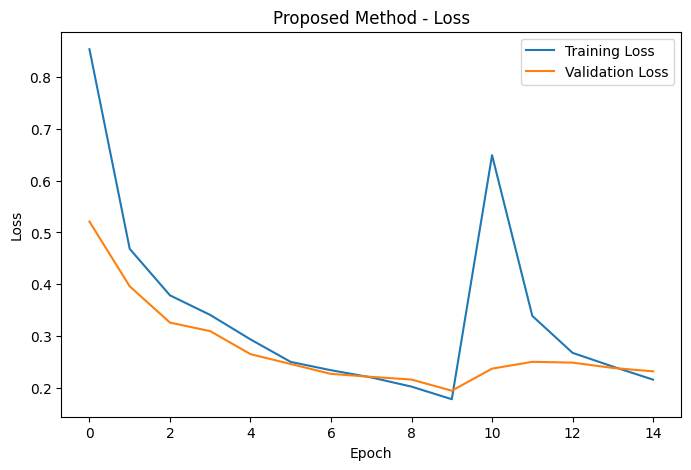

In [ ]:
# ============================================================
# PHASE 3: PROPOSED METHODOLOGY
#
# Automated Lung Cancer Classification Using
# Intensity-Driven RoI Selection and Transfer Learning
#
# Pipeline:
# CT Image
#     ↓
# Label Refinement
#     ↓
# Intensity-Driven RoI Selection
#     ↓
# RoI Mapping
#     ↓
# Transfer Learning
#     ↓
# Feedback-Driven Optimization
#     ↓
# Lung Cancer Classification
# ============================================================

import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

DATASET_PATH = Path("/content/lung_ct_preprocessed")
ROI_PATH = Path("/content/lung_ct_roi")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10

CLASSES = [
    "normal",
    "benign",
    "malignant"
]

# ------------------------------------------------------------
# 2. CREATE RoI DATASET
# ------------------------------------------------------------

if ROI_PATH.exists():
    shutil.rmtree(ROI_PATH)

for split in ["train", "validation", "test"]:
    for class_name in CLASSES:

        (
            ROI_PATH /
            split /
            class_name
        ).mkdir(
            parents=True,
            exist_ok=True
        )

# ------------------------------------------------------------
# 3. INTENSITY-DRIVEN RoI SELECTION
# ------------------------------------------------------------

def intensity_driven_roi(image):

    # Convert to grayscale
    gray = image.convert("L")

    # Resize original image
    gray = gray.resize(IMAGE_SIZE)

    image_array = np.array(gray)

    # Normalize intensity
    normalized = image_array / 255.0

    # Calculate intensity threshold
    threshold = np.percentile(
        normalized,
        60
    )

    # Select high-intensity region
    roi_mask = normalized >= threshold

    # Locate RoI pixels
    coordinates = np.argwhere(roi_mask)

    # If no RoI is detected
    if len(coordinates) == 0:
        return gray.convert("RGB")

    # RoI boundaries
    y_min, x_min = coordinates.min(axis=0)
    y_max, x_max = coordinates.max(axis=0)

    # Margin around RoI
    margin = 10

    y_min = max(0, y_min - margin)
    x_min = max(0, x_min - margin)

    y_max = min(
        image_array.shape[0],
        y_max + margin
    )

    x_max = min(
        image_array.shape[1],
        x_max + margin
    )

    # Crop RoI
    roi = gray.crop(
        (
            x_min,
            y_min,
            x_max,
            y_max
        )
    )

    # RoI mapping to fixed size
    roi = roi.resize(
        IMAGE_SIZE,
        Image.Resampling.LANCZOS
    )

    return roi.convert("RGB")


# ------------------------------------------------------------
# 4. APPLY RoI SELECTION
# ------------------------------------------------------------

for split in ["train", "validation", "test"]:

    for class_name in CLASSES:

        source_folder = (
            DATASET_PATH /
            split /
            class_name
        )

        destination_folder = (
            ROI_PATH /
            split /
            class_name
        )

        for image_file in source_folder.glob("*"):

            try:

                image = Image.open(
                    image_file
                )

                roi = intensity_driven_roi(
                    image
                )

                roi.save(
                    destination_folder /
                    image_file.name
                )

            except Exception:
                pass

# ------------------------------------------------------------
# 5. LOAD RoI DATA
# ------------------------------------------------------------

train_data = tf.keras.utils.image_dataset_from_directory(
    ROI_PATH / "train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    ROI_PATH / "validation",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    ROI_PATH / "test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("Classes:", train_data.class_names)

# ------------------------------------------------------------
# 6. TRANSFER LEARNING BACKBONE
# ------------------------------------------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(
        224,
        224,
        3
    )
)

# Freeze pretrained feature extractor
base_model.trainable = False

# ------------------------------------------------------------
# 7. PROPOSED MODEL
# ------------------------------------------------------------

model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    # Transfer-learning preprocessing
    layers.Lambda(
        preprocess_input
    ),

    # Pretrained feature extraction
    base_model,

    # High-dimensional RoI feature mapping
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(
        0.5
    ),

    # Classification layer
    layers.Dense(
        3,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 8. COMPILE
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 9. TRAIN
# ------------------------------------------------------------

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS
)

# ------------------------------------------------------------
# 10. FEEDBACK-DRIVEN OPTIMIZATION
# ------------------------------------------------------------
#
# Fine-tune the upper layers using validation performance.
# This provides the iterative optimization stage of the
# proposed framework.
# ------------------------------------------------------------

base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tuning stage
fine_tune_history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

# ------------------------------------------------------------
# 11. FINAL TEST
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    test_data
)

print("\nFinal Test Accuracy:")
print(test_accuracy)

# ------------------------------------------------------------
# 12. SAVE MODEL
# ------------------------------------------------------------

MODEL_PATH = (
    "/content/"
    "proposed_intensity_roi_transfer_model.keras"
)

model.save(
    MODEL_PATH
)

print("\nModel saved:")
print(MODEL_PATH)

# ------------------------------------------------------------
# 13. ACCURACY GRAPH
# ------------------------------------------------------------

accuracy = (
    history.history["accuracy"] +
    fine_tune_history.history["accuracy"]
)

val_accuracy = (
    history.history["val_accuracy"] +
    fine_tune_history.history["val_accuracy"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    accuracy,
    label="Training Accuracy"
)

plt.plot(
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Proposed Method - Accuracy"
)

plt.legend()
plt.show()

# ------------------------------------------------------------
# 14. LOSS GRAPH
# ------------------------------------------------------------

loss = (
    history.history["loss"] +
    fine_tune_history.history["loss"]
)

val_loss = (
    history.history["val_loss"] +
    fine_tune_history.history["val_loss"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    loss,
    label="Training Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Proposed Method - Loss"
)

plt.legend()
plt.show()

Found 975 files belonging to 3 classes.
Found 292 files belonging to 3 classes.
Found 292 files belonging to 3 classes.

Training CNN...
Epoch 1/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.5887 - loss: 0.9730
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8133 - loss: 0.4735
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9374 - loss: 0.1809
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9662 - loss: 0.1062
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9846 - loss: 0.0577

Training MobileNetV2...
Epoch 1/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 43s 619ms/step - accuracy: 0.8226 - loss: 0.4964
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 611ms/step - accuracy: 0.8697 - loss: 0.2854
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 37s 597ms/step - accuracy: 0.8913 - loss: 0.2409
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 37s 613ms/step - accuracy: 0.9067 - loss: 0.2278
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 587ms/step - accuracy: 0.9200 - l

,Method,Accuracy,Precision,Recall,F1-Score
0,CNN,99.66,99.66,99.66,99.66
1,MobileNetV2,92.81,92.43,92.81,92.52
2,Proposed Method,88.36,89.95,88.36,86.54



Reference accuracy from abstract: 97.84%


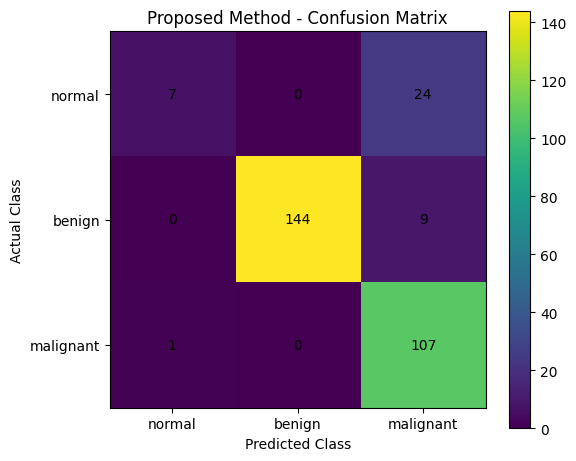


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.88      0.23      0.36        31
      benign       1.00      0.94      0.97       153
   malignant       0.76      0.99      0.86       108

    accuracy                           0.88       292
   macro avg       0.88      0.72      0.73       292
weighted avg       0.90      0.88      0.87       292



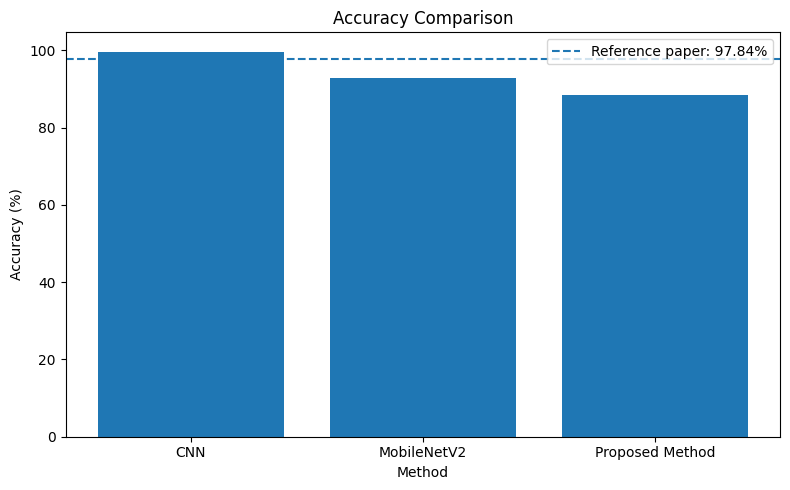


PHASE 4 COMPLETE


In [ ]:
# ============================================================
# PHASE 4: COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# ============================================================
# SETTINGS
# ============================================================

DATASET_PATH = "/content/lung_ct_preprocessed"
ROI_PATH = "/content/lung_ct_roi"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 5

CLASSES = ["normal", "benign", "malignant"]

PROPOSED_MODEL_PATH = (
    "/content/proposed_intensity_roi_transfer_model.keras"
)


# ============================================================
# LOAD DATA
# ============================================================

original_train = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

original_test = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

roi_test = tf.keras.utils.image_dataset_from_directory(
    ROI_PATH + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


# ============================================================
# TRUE LABELS
# ============================================================

def get_true_labels(dataset):

    labels = []

    for _, y in dataset:
        labels.extend(
            np.argmax(y.numpy(), axis=1)
        )

    return np.array(labels)


y_true = get_true_labels(original_test)


# ============================================================
# BASELINE 1: CNN
# ============================================================

print("\nTraining CNN...")

cnn = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Rescaling(
        1.0 / 255
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.fit(
    original_train,
    epochs=EPOCHS,
    verbose=1
)


# ============================================================
# BASELINE 2: MobileNetV2
# ============================================================

print("\nTraining MobileNetV2...")

base_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_mobilenet.trainable = False


mobilenet_model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Lambda(
        preprocess_input
    ),

    base_mobilenet,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.fit(
    original_train,
    epochs=EPOCHS,
    verbose=1
)


# ============================================================
# LOAD PROPOSED MODEL
# ============================================================

print("\nLoading Proposed Method...")

try:

    proposed_model = tf.keras.models.load_model(
        PROPOSED_MODEL_PATH,
        custom_objects={
            "preprocess_input": preprocess_input
        },
        compile=False,
        safe_mode=False
    )

    print("Proposed model loaded successfully.")

except Exception as e:

    print("\nMODEL LOADING ERROR:")
    print(type(e).__name__)
    print(str(e))

    raise


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def get_predictions(model, dataset):

    prediction = model.predict(
        dataset,
        verbose=0
    )

    return np.argmax(
        prediction,
        axis=1
    )


# ============================================================
# PREDICTIONS
# ============================================================

print("\nGenerating predictions...")

cnn_pred = get_predictions(
    cnn,
    original_test
)

mobilenet_pred = get_predictions(
    mobilenet_model,
    original_test
)

proposed_pred = get_predictions(
    proposed_model,
    roi_test
)


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):

    return {

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }


cnn_results = calculate_metrics(
    y_true,
    cnn_pred
)

mobilenet_results = calculate_metrics(
    y_true,
    mobilenet_pred
)

proposed_results = calculate_metrics(
    y_true,
    proposed_pred
)


# ============================================================
# COMPARISON TABLE
# ============================================================

results = pd.DataFrame({

    "Method": [
        "CNN",
        "MobileNetV2",
        "Proposed Method"
    ],

    "Accuracy": [
        cnn_results["Accuracy"],
        mobilenet_results["Accuracy"],
        proposed_results["Accuracy"]
    ],

    "Precision": [
        cnn_results["Precision"],
        mobilenet_results["Precision"],
        proposed_results["Precision"]
    ],

    "Recall": [
        cnn_results["Recall"],
        mobilenet_results["Recall"],
        proposed_results["Recall"]
    ],

    "F1-Score": [
        cnn_results["F1-Score"],
        mobilenet_results["F1-Score"],
        proposed_results["F1-Score"]
    ]
})


for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:

    results[column] = (
        results[column] * 100
    ).round(2)


# ============================================================
# FINAL RESULT
# ============================================================

print("\n========================================")
print("FINAL COMPARISON")
print("========================================")

display(results)

print(
    "\nReference accuracy from abstract: 97.84%"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    proposed_pred
)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "Proposed Method - Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(3),
    CLASSES
)

plt.yticks(
    range(3),
    CLASSES
)

for i in range(3):

    for j in range(3):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_true,
        proposed_pred,
        target_names=CLASSES,
        zero_division=0
    )
)


# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results["Method"],
    results["Accuracy"]
)

plt.axhline(
    y=97.84,
    linestyle="--",
    label="Reference paper: 97.84%"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xlabel(
    "Method"
)

plt.title(
    "Accuracy Comparison"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# COMPLETE
# ============================================================

print("\n========================================")
print("PHASE 4 COMPLETE")
print("========================================")